# Preprocessing, feature engineering & avoiding data leakage
**MDS7201 — Data Science Project · Universidad de Chile**

Three-hour class. **The thread that ties everything together:** no information from validation or test data may influence any decision made at training time. Every technique we introduce will be checked against this rule.

## Outline

| § | Topic | Time |
|---|---|---|
| 1 | A leaky baseline — how easy it is to fool ourselves | 15 min |
| 2 | Fix it with `Pipeline` + `ColumnTransformer` | 20 min |
| 3 | Missing data | 20 min |
| 4 | Scaling, skewness, encoding | 20 min |
| — | **break** | 15 min |
| 5 | Feature engineering, motivated | 25 min |
| 6 | Splitting beyond random | 15 min |
| 7 | Class imbalance without leaking | 15 min |
| 8 | Hyperparameter tuning without leaking | 20 min |
| 9 | Final evaluation, and what's next | 15 min |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(display='diagram')   # nicer pipeline visualisations

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 4)

> **The rule.** No statistic, parameter, model, decision, or feature derived from validation/test data may flow back into training. Every fittable step (imputer, scaler, encoder, selector, resampler, …) belongs *inside* a cross-validated pipeline.

## 1. A leaky baseline

We start by doing things the obvious-but-wrong way and seeing how easy it is to fool ourselves. The dataset: ALeRCE light-curve features for a sample of astronomical objects. The target is `classALeRCE`.

In [2]:
featfile = "../data/features_small.pickle"
xmatchfile = "../data/dfcrossmatches_small.pickle"

In [3]:
def getdata():
    df = pd.read_pickle(featfile)
    df = df.reset_index()
    df["fname"] = df.name + "_" + df.fid.astype(str)
    df = df.pivot(index="oid", columns=["fname"], values="value")
    labels = pd.read_pickle(xmatchfile)
    labels = labels.loc[labels.index.isin(df.index)].classALeRCE
    return df, labels

df, labels = getdata()
print("features:", df.shape)
print("labels  :", labels.shape)

features: (39024, 179)
labels  : (39024,)


### Quick EDA

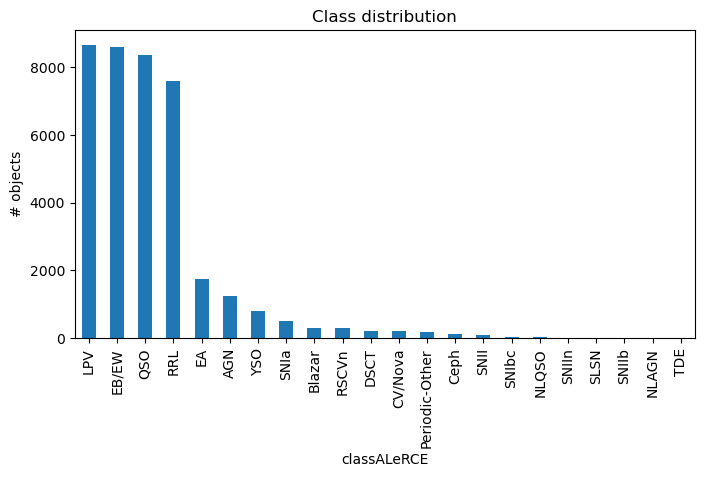

In [4]:
# Class distribution — note the imbalance, this will matter later
fig, ax = plt.subplots(figsize=(8, 4))
labels.value_counts().plot.bar(ax=ax)
ax.set_ylabel("# objects"); ax.set_title("Class distribution");

175 of 179 columns have missing values


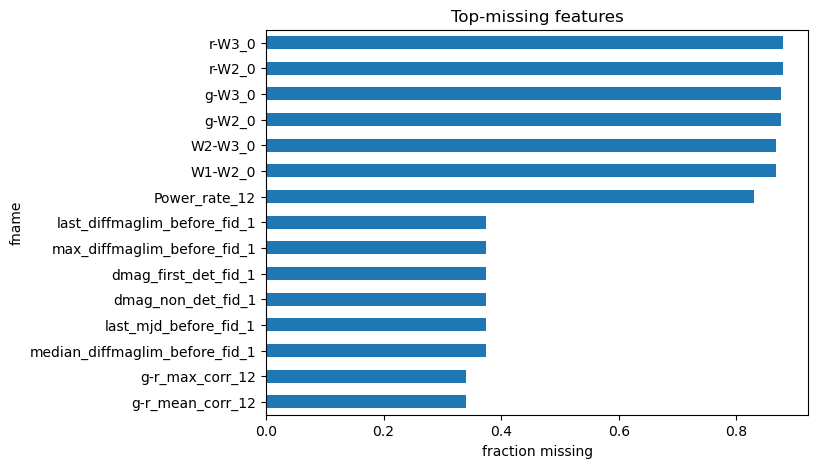

In [5]:
# Where does missingness live?
missing = df.isna().mean().sort_values(ascending=False)
print(f"{(missing > 0).sum()} of {len(missing)} columns have missing values")
missing.head(15).plot.barh(figsize=(7, 5))
plt.gca().invert_yaxis(); plt.xlabel("fraction missing"); plt.title("Top-missing features");

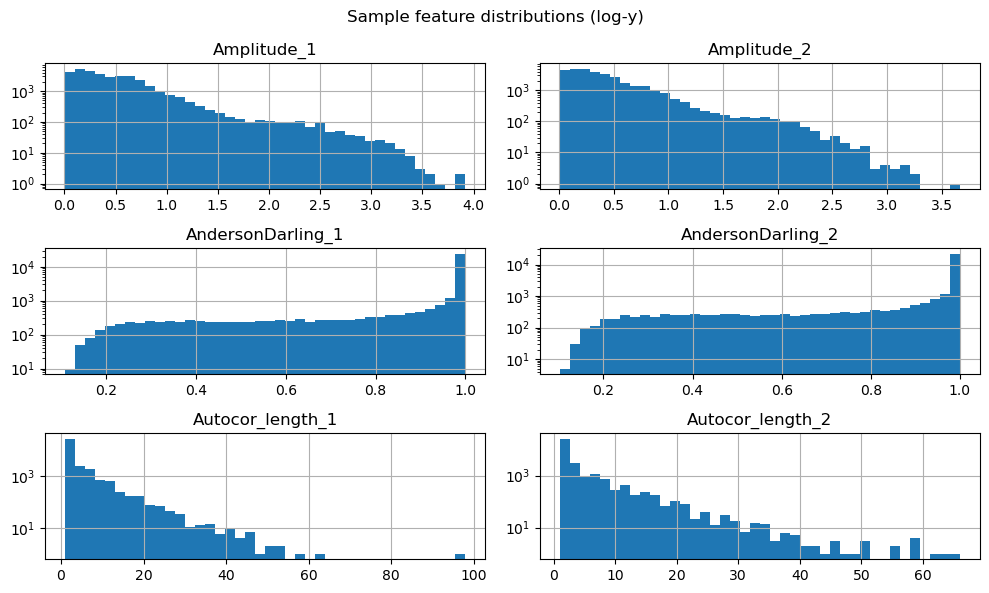

In [6]:
# Distributions are heavy-tailed — we'll need to think about scaling & skewness
sample_cols = df.columns[:6]
df[sample_cols].hist(bins=40, figsize=(10, 6), log=True)
plt.suptitle("Sample feature distributions (log-y)"); plt.tight_layout();

### Downsample the dataset

In [7]:
ordered_classes = ['SNIbc', 'SNII', 'SNIIn', 'SNIIb', 'SNIa', 'SLSN', 'TDE',
       'CV/Nova', 'AGN', 'QSO', 'Blazar', 'YSO', 
       'DSCT', 'RRL','EB/EW', 'EA', 'Ceph', 'LPV', 'RSCVn', 'Periodic-Other'] 

features: (1865, 179)
labels  : (1865,)


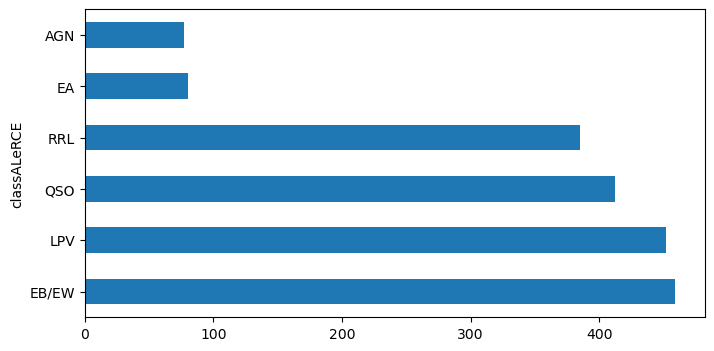

In [99]:
def getdata(nsample, nmin):
    df = pd.read_pickle(featfile)
    df = df.reset_index()
    df["fname"] = df.name + "_" + df.fid.astype(str)
    df = df.pivot(index="oid", columns=["fname"], values="value")
    labels = pd.read_pickle(xmatchfile)
    labels = labels.loc[df.index].classALeRCE
    mask = labels.isin(ordered_classes)
    labels = labels.loc[mask]
    df = df.loc[mask]    #labels = labels.loc[labels.index.isin(df.index)].classALeRCE

    df = df.sample(nsample, random_state=RANDOM_STATE)
    labels = labels.loc[df.index]
    # Select labels that have at least nmin examples
    sellabels = labels.value_counts().loc[labels.value_counts() >= nmin].index
    df = df.loc[labels.isin(sellabels)]
    labels = labels.loc[labels.isin(sellabels)]
    labels.value_counts().plot.barh()
    
    return df, labels

df, labels = getdata(2000, 50)
print("features:", df.shape)
print("labels  :", labels.shape)

In [100]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [101]:
dft = pd.DataFrame(data=StandardScaler().fit_transform(SimpleImputer(strategy='median').fit_transform(df)), index=df.index, columns=list(df))

In [102]:
import umap
reducer = umap.UMAP()

df_umap = reducer.fit_transform(dft)

In [103]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()

le.fit(ordered_classes)
# force given order
le.classes_ = np.array(ordered_classes)
y = le.transform(labels)

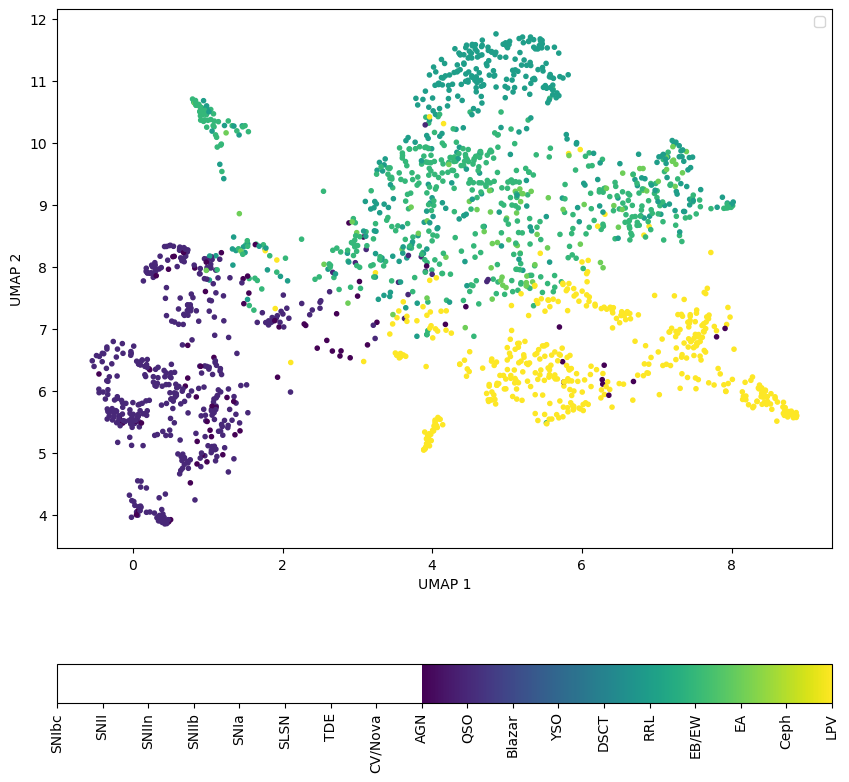

In [104]:
fig, ax = plt.subplots(figsize = (10, 10), sharex = True)
cax = ax.scatter(df_umap[:, 0], df_umap[:, 1], c=y, marker='.', alpha=1)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.legend();
cbar = plt.colorbar(cax, orientation='horizontal')
cbar.ax.set_xticks(np.array(range(y.max()+1)), 
                   labels=[le.inverse_transform([i])[0] for i in (np.array(range(y.max()+1)))])
cbar.ax.set_xticklabels(cbar.ax.get_xticklabels(), rotation=90);

### The careless pipeline

Impute the column median, scale, run 5-fold CV. Spot the bug *before* you run the cell.

CV f1_macro (leaky setup): 0.750


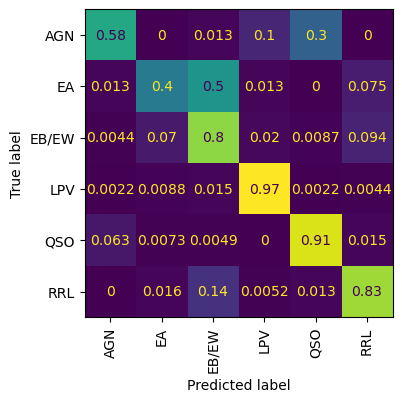

In [105]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay                                                                            

imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_all = scaler.fit_transform(imputer.fit_transform(df))   # fit on every row, including future val folds
y_all = labels.values

clf = LogisticRegression(max_iter=2000)
score_leaky = cross_val_score(clf, X_all, y_all, cv=5, scoring='f1_macro').mean()
print(f"CV f1_macro (leaky setup): {score_leaky:.3f}")

y_pred = cross_val_predict(clf, X_all, y_all, cv=5)
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(                                                                                    
    y_all, y_pred, ax=ax,
    xticks_rotation='vertical',                                                                                               
    normalize='true',          # row-normalized = recall per class; easier to read for imbalanced data
    colorbar=False,                                                                                                           
) 

**What's wrong?** The imputer's medians and the scaler's means/stds were computed using rows that will later appear in CV's validation folds. The validation score is no longer an honest estimate of generalization.

For median imputation the magnitude of the leak is small. To convince ourselves the *pattern* is dangerous, here's a more dramatic version using a random sample and feature selection.

CV f1_macro — leaky: 0.662, honest: 0.620


Text(0.5, 1.0, 'honest')

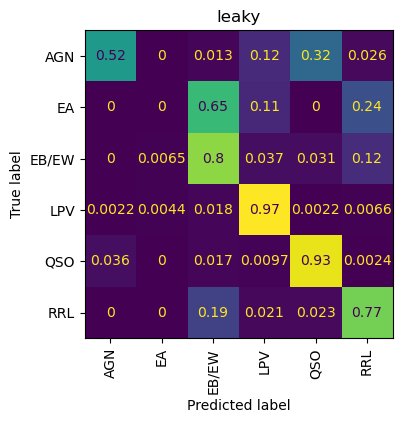

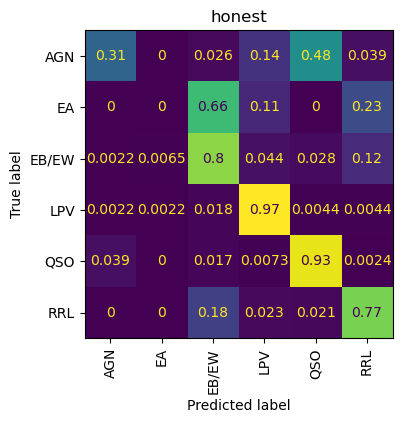

In [106]:
# A more dramatic leak: select the 'best' features using the WHOLE dataset, then CV on the result.                            
from sklearn.feature_selection import SelectKBest, f_classif                                                                  
                                                                                                                                                                              
                                                                                                                              
# Leaky: select features using the full (X, y_random), then CV
X_filled = StandardScaler().fit_transform(SimpleImputer(strategy='median').fit_transform(df))                                                                 
X_sel    = SelectKBest(f_classif, k=10).fit_transform(X_filled, y_all)
clf = LogisticRegression(max_iter=2000)
leaky = cross_val_score(clf, X_sel, y_all,
                                cv=5, scoring='f1_macro').mean()                                                              
                                                                                                                            
# Honest: select features INSIDE a pipeline so it's refit per fold                                                            
from sklearn.pipeline import Pipeline                                                                                       
honest_pipe = Pipeline([                                                                                                      
    ("impute", SimpleImputer(strategy='median')),
    ("scale", StandardScaler()),
    ("select", SelectKBest(f_classif, k=10)),
    ("model",  LogisticRegression(max_iter=2000)),                                                                            
])
honest = cross_val_score(honest_pipe, df, y_all, cv=5, scoring='f1_macro').mean()
                                                                                                                              
print(f"CV f1_macro — leaky: {leaky:.3f}, honest: {honest:.3f}")                               

y_pred = cross_val_predict(clf, X_sel, y_all, cv=5)
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(                                                                                    
    y_all, y_pred, ax=ax,
    xticks_rotation='vertical',                                                                                               
    normalize='true',          # row-normalized = recall per class; easier to read for imbalanced data
    colorbar=False,                                                                                                           
) 
ax.set_title("leaky")

y_pred = cross_val_predict(honest_pipe, df, y_all, cv=5)
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(                                                                                    
    y_all, y_pred, ax=ax,
    xticks_rotation='vertical',                                                                                               
    normalize='true',          # row-normalized = recall per class; easier to read for imbalanced data
    colorbar=False,                                                                                                           
)
ax.set_title("honest")

We could be introducing leakage!

In [107]:
# let's try fitting random noise
from sklearn.feature_selection import SelectKBest, f_classif                                                                  
                                                                                                                            
# Pure noise — there is no signal anywhere by construction                                                                    
rng = np.random.default_rng(0)
n_samples, n_features = 1000, 2000                                                                                             
X_noise = rng.standard_normal((n_samples, n_features))                                                                      
y_noise = rng.integers(0, 2, size=n_samples)   # balanced binary                                                              
                                                                                                                            
# Leaky: pick 'best' 20 features using ALL rows, then CV                                                                      
X_sel = SelectKBest(f_classif, k=5).fit_transform(X_noise, y_noise)                                                        
leaky = cross_val_score(LogisticRegression(max_iter=2000), X_sel, y_noise,                                                    
                        cv=5, scoring='f1_macro').mean()                                                                      

# Honest: same selector, but inside a pipeline so it refits per fold                                                          
honest = cross_val_score(                                                                                                   
    Pipeline([("select", SelectKBest(f_classif, k=5)),                                                                       
              ("model",  LogisticRegression(max_iter=2000))]),                                                                
    X_noise, y_noise, cv=5, scoring='f1_macro').mean()
                                                                                                                              
print(f"leaky CV accuracy : {leaky:.3f}   <- there is no signal!")                                                            
print(f"honest CV accuracy: {honest:.3f}  <- ~chance, as it should be")  

leaky CV accuracy : 0.587   <- there is no signal!
honest CV accuracy: 0.506  <- ~chance, as it should be


## 2. Fix it with `Pipeline` + `ColumnTransformer`

The remedy: every step that learns parameters from data goes *inside* a `Pipeline`. CV then re-fits those steps on each training fold only. We also hold out a real test set right now and don't touch it again until §9.

In [31]:
from sklearn.model_selection import train_test_split, StratifiedKFold

X_train, X_test, y_train, y_test = train_test_split(
    df, labels, test_size=0.2, stratify=labels, random_state=RANDOM_STATE
)
print("train:", X_train.shape, " test:", X_test.shape)

train: (1492, 179)  test: (373, 179)


In [32]:
pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy='median')),
    ("scale",  StandardScaler()),
    ("model",  LogisticRegression(max_iter=2000)),
])
pipe   # rendered as a diagram

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000))])

CV f1_macro (pipeline, fit-per-fold): 0.746


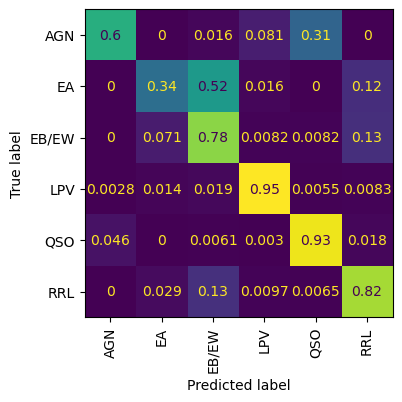

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
score_clean = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro').mean()
print(f"CV f1_macro (pipeline, fit-per-fold): {score_clean:.3f}")

y_pred = cross_val_predict(pipe, X_train, y_train, cv=5)
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(                                                                                    
    y_train, y_pred, ax=ax,
    xticks_rotation='vertical',                                                                                               
    normalize='true',          # row-normalized = recall per class; easier to read for imbalanced data
    colorbar=False,                                                                                                           
)

### `ColumnTransformer` for heterogeneous columns
This dataset is all numeric, but real datasets aren't. `ColumnTransformer` routes each column-group to its own sub-pipeline. We sketch it now and re-use it in every section below.

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_cols = X_train.columns.tolist()

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy='median')),
    ("scale",  StandardScaler()),
])

# Sketch — when categoricals exist, route them via OneHotEncoder:
preproc = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_cols),
        # ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ],
    remainder='drop',
)
preproc

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['Amplitude_1', 'Amplitude_2',
                                  'AndersonDarling_1', 'AndersonDarling_2',
                                  'Autocor_length_1', 'Autocor_length_2',
                                  'Beyond1Std_1', 'Beyond1Std_2', 'Con_1',
                                  'Con_2', 'Eta_e_1', 'Eta_e_2', 'ExcessVar_1',
                                  'ExcessVar_2', 'GP_DRW_sigma_1',
                                  'GP_DRW_sigma_2', 'GP_DRW_tau_1',
                                  'GP_DRW_tau_2', 'Gskew_1', 'Gskew_2',
                                  'Harmonics_mag_1_1', 'Harmonics_mag_1_2',
                                  'Harmonics_mag_2_1', 'Harmonics_mag_2_2',
                                  'Harmonics_mag_3_1', 'Harmonics_mag_3_2',
                                  'Harmonics_mag_4_1', 'Harmonics_mag_4_2',
                                  'Harmonics_mag_5_1', 'Harmonics_mag_5_2', ...])])

In [35]:
pipe = Pipeline([("preproc", preproc), ("model", LogisticRegression(max_iter=2000))])
score = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro').mean()
print(f"CV f1_macro (ColumnTransformer pipeline): {score:.3f}")

CV f1_macro (ColumnTransformer pipeline): 0.746


From here on, **every** technique we introduce drops in as a step in `numeric_pipe` or as a sibling in `preproc`. The leakage discussion goes away — it's structurally impossible to leak inside a `cross_val_score(pipeline, X, y)` call.

## 3. Missing data 

Two complementary moves:
- **Imputation** — fill in the missing value with something plausible.
- **Missingness indicator** — add a binary column flagging "this value was missing." Worth it when missingness is *informative* (e.g., a sensor that drops out under extreme conditions, a survey question respondents skip when the answer is sensitive).

In [36]:
# How much missingness do we have to deal with?
n_total   = df.size
n_missing = df.isna().sum().sum()
print(f"{n_missing}/{n_total} cells missing  ({100*n_missing/n_total:.2f}%)")
print(f"{(df.isna().any(axis=1)).mean()*100:.1f}% of rows have at least one missing value")

45617/333835 cells missing  (13.66%)
100.0% of rows have at least one missing value


### Comparing imputation strategies

We'll compare four strategies, each wrapped in a pipeline so the comparison is honest:

In [39]:
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, KNNImputer

def cv_with_imputer(imputer, name):
    p = Pipeline([
        ("impute", imputer),
        ("scale",  StandardScaler()),
        ("model",  LogisticRegression(max_iter=2000)),
    ])
    score = cross_val_score(p, X_train, y_train, cv=cv, scoring='f1_macro').mean()
    print(f"{name:25s}  f1_macro = {score:.3f}")
    return score

results = {}
results["mean"]      = cv_with_imputer(SimpleImputer(strategy='mean'),     "SimpleImputer(mean)")
results["median"]    = cv_with_imputer(SimpleImputer(strategy='median'),   "SimpleImputer(median)")
results["-99"]    = cv_with_imputer(SimpleImputer(fill_value=-99),   "SimpleImputer(-99)")
results["knn-5"]     = cv_with_imputer(KNNImputer(n_neighbors=5),          "KNNImputer(k=5)")
results["iterative"] = cv_with_imputer(IterativeImputer(max_iter=10, random_state=RANDOM_STATE),
                                       "IterativeImputer (MICE)")

SimpleImputer(mean)        f1_macro = 0.736
SimpleImputer(median)      f1_macro = 0.746
SimpleImputer(-99)         f1_macro = 0.736
KNNImputer(k=5)            f1_macro = 0.736
IterativeImputer (MICE)    f1_macro = 0.719


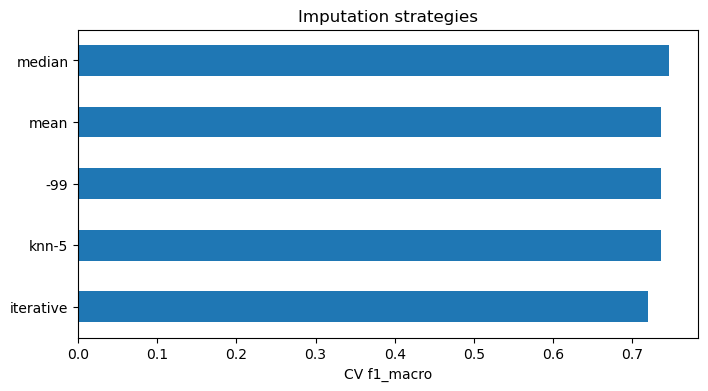

In [40]:
pd.Series(results).sort_values().plot.barh()
plt.xlabel("CV f1_macro"); plt.title("Imputation strategies");

### Adding a missingness indicator

If "this value was missing" is itself informative, we want to keep that signal even after we fill in the cell.

In [41]:
from sklearn.pipeline import FeatureUnion
from sklearn.impute import MissingIndicator

preproc_with_indicator = FeatureUnion([
    ("imputed",   SimpleImputer(strategy='median')),
    ("indicator", MissingIndicator(features='all')),
])

pipe = Pipeline([
    ("preproc", preproc_with_indicator),
    ("scale",   StandardScaler()),
    ("model",   LogisticRegression(max_iter=2000)),
])
score = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro').mean()
print(f"with missingness indicator: {score:.3f}")
print(f"without (median only)      : {results['median']:.3f}")

with missingness indicator: 0.739
without (median only)      : 0.746


### Order matters: transform *before* impute

If we plan to power-transform skewed columns, imputing the median *first* inserts a spike into the distribution that `PowerTransformer` then has to undo. The cleaner order is: transform → impute → scale.

In [44]:
from sklearn.preprocessing import PowerTransformer

# Order A — impute first (the convenient default)
A = Pipeline([
    ("impute", SimpleImputer(strategy='median')),
    ("power",  PowerTransformer(method='yeo-johnson', standardize=False)),
    ("scale",  StandardScaler()),
    ("model",  LogisticRegression(max_iter=2000)),
])
# Order B — power-transform first (PT handles NaNs ok in recent sklearn; otherwise impute with mean of partial fit)
B = Pipeline([
    ("power",  PowerTransformer(method='yeo-johnson', standardize=False)),
    ("impute", SimpleImputer(strategy='median')),
    ("scale",  StandardScaler()),
    ("model",  LogisticRegression(max_iter=2000)),
])
sA = cross_val_score(A, X_train, y_train, cv=cv, scoring='f1_macro').mean()
sB = cross_val_score(B, X_train, y_train, cv=cv, scoring='f1_macro').mean()
print(f"impute → power → scale : {sA:.3f}")
print(f"power → impute → scale : {sB:.3f}")

impute → power → scale : 0.772
power → impute → scale : 0.761


In this case imputing first was better :P

## 4. Scaling, skewness, encoding

**Why scale?** Linear models, distance-based models (kNN, k-means), and gradient-based optimizers care about scale. Tree models (random forest, gradient boosting) do not — but it doesn't hurt them either.

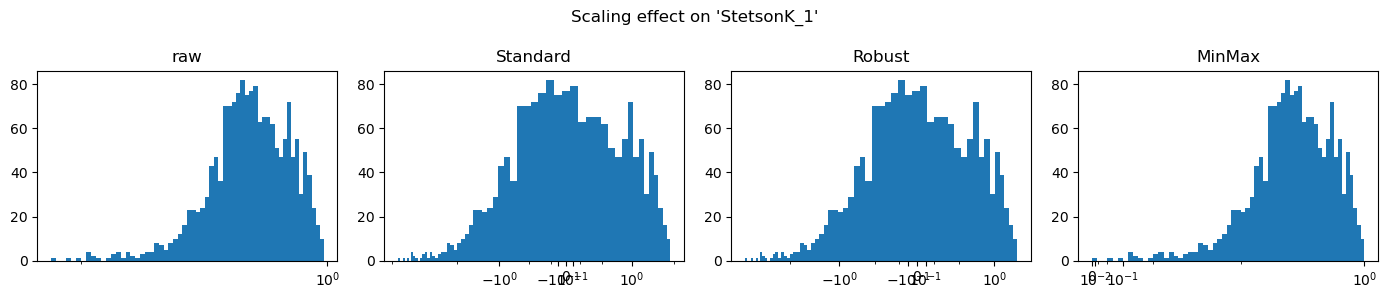

In [48]:
# Compare three scalers on a heavily-skewed feature
from sklearn.preprocessing import RobustScaler, MinMaxScaler

col = df.notna().sum().sort_values(ascending=False).index[100]   # pick a well-populated column
x = df[col].dropna().values.reshape(-1, 1)

scaled = {
    "raw":      x.ravel(),
    "Standard": StandardScaler().fit_transform(x).ravel(),
    "Robust":   RobustScaler().fit_transform(x).ravel(),
    "MinMax":   MinMaxScaler().fit_transform(x).ravel(),
}
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, v) in zip(axes, scaled.items()):
    ax.hist(v, bins=60); ax.set_title(name); ax.set_xscale('asinh')
plt.suptitle(f"Scaling effect on '{col}'"); plt.tight_layout();

**Standard** vs **Robust** vs **MinMax**: pick `RobustScaler` when outliers are common and you don't want them to dominate the variance estimate.

### Reducing skewness — `PowerTransformer`

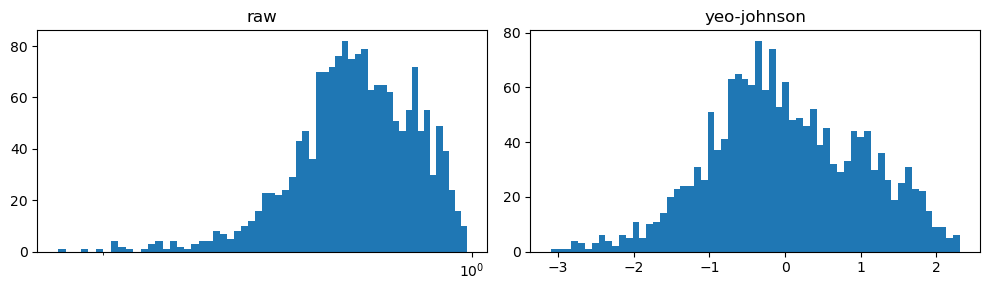

In [49]:
x_pt = PowerTransformer(method='yeo-johnson').fit_transform(x).ravel()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(x.ravel(), bins=60); axes[0].set_title("raw"); axes[0].set_xscale('asinh')
axes[1].hist(x_pt, bins=60);      axes[1].set_title("yeo-johnson")
plt.tight_layout();

### Encoding categorical variables (sketch)

The dataset is all-numeric so we sketch with a synthetic categorical column.

In [50]:
# Pretend we had a categorical column 'survey'
cat = pd.Series(np.random.choice(['ATLAS', 'ZTF', 'Pan-STARRS'], size=len(X_train)),
                index=X_train.index, name='survey')
cat.value_counts()

survey
ATLAS         502
Pan-STARRS    500
ZTF           490
Name: count, dtype: int64

In [51]:
# OneHotEncoder — model-agnostic, fine for low cardinality
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit_transform(cat.to_frame())[:5]

array([[1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

**Encoding choices**

| Encoder | Use when | Pitfall |
|---|---|---|
| `OneHotEncoder` | low cardinality, any model | sparse explosion at high cardinality |
| Label / Ordinal | tree models only | linear models read the integer as a magnitude |
| `TargetEncoder` (`category_encoders`) | high cardinality | **classic leakage trap** — must be fit on training fold only, inside the pipeline |
| Hashing | very high cardinality, online setting | collisions; not invertible |

### Putting it together — full numeric pipeline

In [52]:
numeric_pipe = Pipeline([
    ("power",  PowerTransformer(method='yeo-johnson', standardize=False)),
    ("impute", SimpleImputer(strategy='median')),
    ("scale",  StandardScaler()),
])
preproc = ColumnTransformer([("num", numeric_pipe, numeric_cols)])

pipe = Pipeline([("preproc", preproc), ("model", LogisticRegression(max_iter=2000))])
score = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro').mean()
print(f"CV f1_macro (power → impute → scale → logreg): {score:.3f}")

CV f1_macro (power → impute → scale → logreg): 0.761


— **break (15 min)** —

## 5. Feature engineering, motivated

Each new feature should be motivated by something the model is currently getting wrong. The pattern is always: add the feature as a transformer step in the pipeline, re-run CV, see whether it helped.

### Cross / interaction features

For two features $x_1, x_2$, a cross feature is $x_1 \cdot x_2$ or $x_1 / x_2$. Useful when the target depends on a *ratio* a linear model can't recover on its own.

In [56]:
df

fname,Amplitude_1,Amplitude_2,AndersonDarling_1,AndersonDarling_2,Autocor_length_1,Autocor_length_2,Beyond1Std_1,Beyond1Std_2,Con_1,Con_2,...,n_non_det_before_fid_1,n_non_det_before_fid_2,n_pos_1,n_pos_2,positive_fraction_1,positive_fraction_2,r-W2_0,r-W3_0,rb_0,sgscore1_0
oid,,,,,,,,,,,,,,,,,,,,,
ZTF18acqurcp,0.110450,0.091665,1.000000,1.000000,11.0,5.0,0.366197,0.242718,0.042857,0.049505,...,8.0,6.0,0.0,0.0,0.000000,0.000000,NaN,NaN,0.914286,1.000000
ZTF18aazfaca,1.044818,0.910565,0.807313,0.999783,3.0,3.0,0.298137,0.310606,0.012579,0.000000,...,0.0,19.0,132.0,102.0,0.819876,0.772727,NaN,NaN,0.708571,0.940792
ZTF18aazfeiq,0.691051,0.601286,1.000000,1.000000,11.0,13.0,0.328283,0.309942,0.015306,0.047337,...,0.0,33.0,160.0,161.0,0.808081,0.941520,NaN,NaN,0.767143,0.500000
ZTF20aaaxfuo,0.414248,0.297969,0.787185,0.997968,9.0,3.0,0.314815,0.333333,0.000000,0.000000,...,0.0,28.0,54.0,30.0,1.000000,1.000000,NaN,NaN,0.890714,0.997500
ZTF17aabukjx,0.696899,0.509038,1.000000,1.000000,1.0,1.0,0.593407,0.383275,0.000000,0.000000,...,4.0,1.0,103.0,81.0,0.282967,0.282230,NaN,NaN,0.873333,0.976583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZTF20aaoysll,0.052950,NaN,0.937910,NaN,1.0,NaN,0.200000,NaN,0.000000,NaN,...,6.0,31.0,10.0,1.0,1.000000,1.000000,5.577881,8.858881,0.941429,0.005875
ZTF18aawcdiy,0.539074,0.498975,1.000000,1.000000,2.0,10.0,0.148148,0.303318,0.000000,0.000000,...,33.0,0.0,77.0,164.0,0.950617,0.777251,NaN,NaN,0.728571,0.959792
ZTF17aabvffj,2.092548,NaN,0.999845,NaN,18.0,NaN,0.352601,NaN,0.020349,NaN,...,0.0,207.0,19.0,4.0,0.054913,0.800000,NaN,NaN,0.824286,0.500000


In [57]:
# Pick two well-populated features and emit their ratio as a new feature.
from sklearn.preprocessing import FunctionTransformer

a, b = "Amplitude_1", "Amplitude_2"
print(f"creating ratio: {a} / {b}")

def add_ratio(X):
    X = pd.DataFrame(X, columns=numeric_cols).copy() if not isinstance(X, pd.DataFrame) else X.copy()
    safe_b = X[b].replace(0, np.nan)
    X[f"ratio_{a[:8]}_over_{b[:8]}"] = X[a] / safe_b
    return X

ratio_step = FunctionTransformer(add_ratio, validate=False)

# Insert the ratio step at the front of the numeric pipeline
numeric_pipe_with_ratio = Pipeline([
    ("ratio",  ratio_step),
    ("power",  PowerTransformer(method='yeo-johnson', standardize=False)),
    ("impute", SimpleImputer(strategy='median')),
    ("scale",  StandardScaler()),
])

pipe = Pipeline([
    ("preproc", ColumnTransformer([("num", numeric_pipe_with_ratio, numeric_cols)])),
    ("model",   LogisticRegression(max_iter=2000)),
])
score = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro').mean()
print(f"CV f1_macro (with ratio feature): {score:.3f}")

creating ratio: Amplitude_1 / Amplitude_2
CV f1_macro (with ratio feature): 0.768


**Discuss.** Did the ratio help? On most pairs it won't — feature engineering is mostly a story of small wins and many dead ends. The point is the *protocol*: try, score with CV, keep if it helps.

### Date-time features

If a feature is an angle, hour-of-day, or day-of-year, encode it as $(\sin(2\pi t/T), \cos(2\pi t/T))$. The cyclic pair preserves "11pm is close to midnight" — a raw integer doesn't.

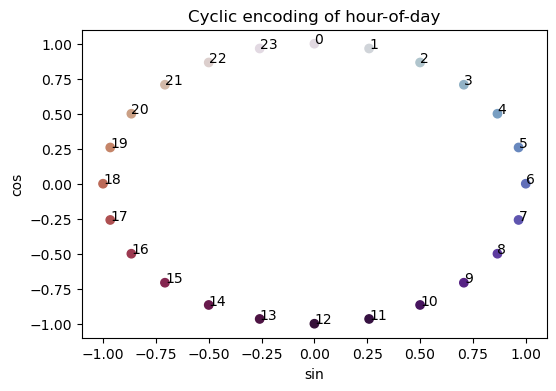

In [58]:
# Sketch with a synthetic 'hour' column
synthetic = pd.DataFrame({
    'hour': np.arange(0, 24),
})
synthetic['hour_sin'] = np.sin(2*np.pi * synthetic['hour'] / 24)
synthetic['hour_cos'] = np.cos(2*np.pi * synthetic['hour'] / 24)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(synthetic['hour_sin'], synthetic['hour_cos'], c=synthetic['hour'], cmap='twilight')
for _, r in synthetic.iterrows():
    ax.annotate(int(r['hour']), (r['hour_sin'], r['hour_cos']))
ax.set_xlabel('sin'); ax.set_ylabel('cos'); ax.set_title('Cyclic encoding of hour-of-day');

**Time-since-event** is the other half of date-time engineering: for each row, how long since the most recent occurrence of some reference event (last login, last detection, last payment). Decays as a relevant feature for many models.

### Tour: domain-specific extractors

Same rule applies — every step with learned parameters lives inside the pipeline.

#### Time series → `tsfresh`

In [61]:
from tsfresh.examples.robot_execution_failures import download_robot_execution_failures, \
    load_robot_execution_failures
download_robot_execution_failures()
timeseries, y = load_robot_execution_failures()

Normal behaviour

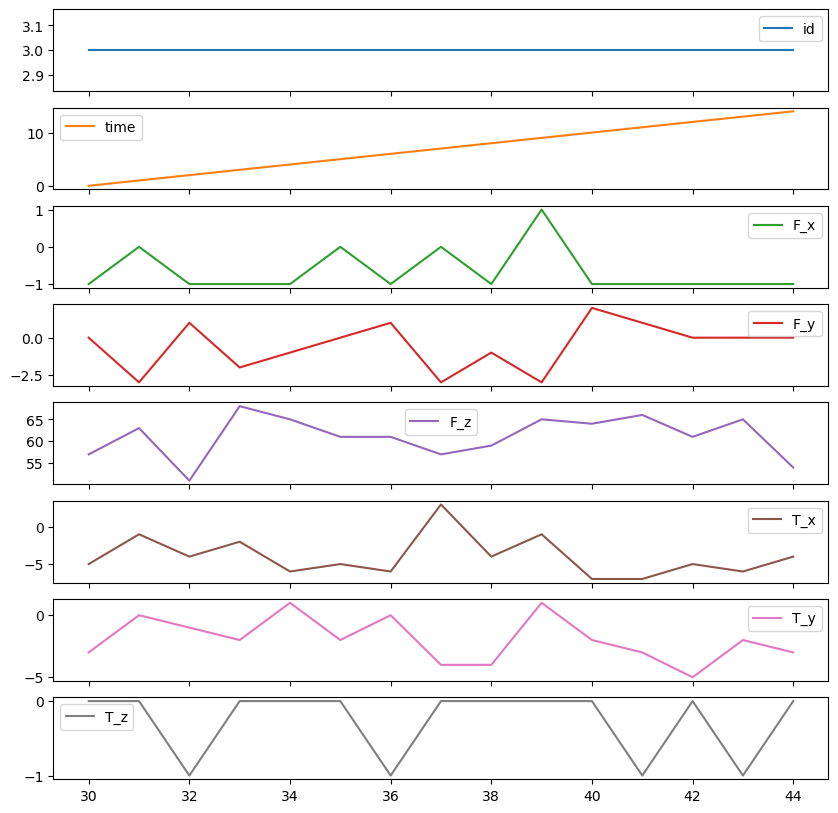

In [62]:
timeseries[timeseries['id'] == 3].plot(subplots=True, sharex=True, figsize=(10,10))
plt.show()

Anomalous

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

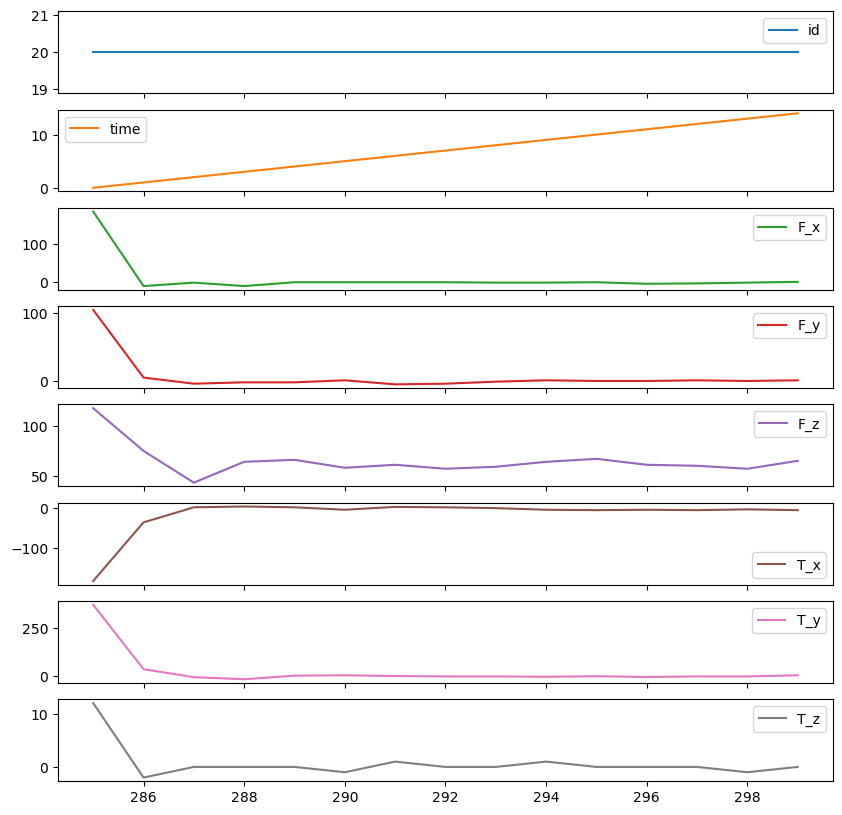

In [63]:
timeseries[timeseries['id'] == 20].plot(subplots=True, sharex=True, figsize=(10,10))

In [64]:
timeseries

,id,time,F_x,F_y,F_z,T_x,T_y,T_z
0,1,0,-1,-1,63,-3,-1,0
1,1,1,0,0,62,-3,-1,0
2,1,2,-1,-1,61,-3,0,0
3,1,3,-1,-1,63,-2,-1,0
4,1,4,-1,-1,63,-3,-1,0
...,...,...,...,...,...,...,...,...
1315,88,10,-10,2,39,-21,-24,5
1316,88,11,-11,2,38,-24,-22,6
1317,88,12,-12,3,23,-24,-24,5
1318,88,13,-13,4,26,-29,-27,5


In [65]:
1320/88

15.0

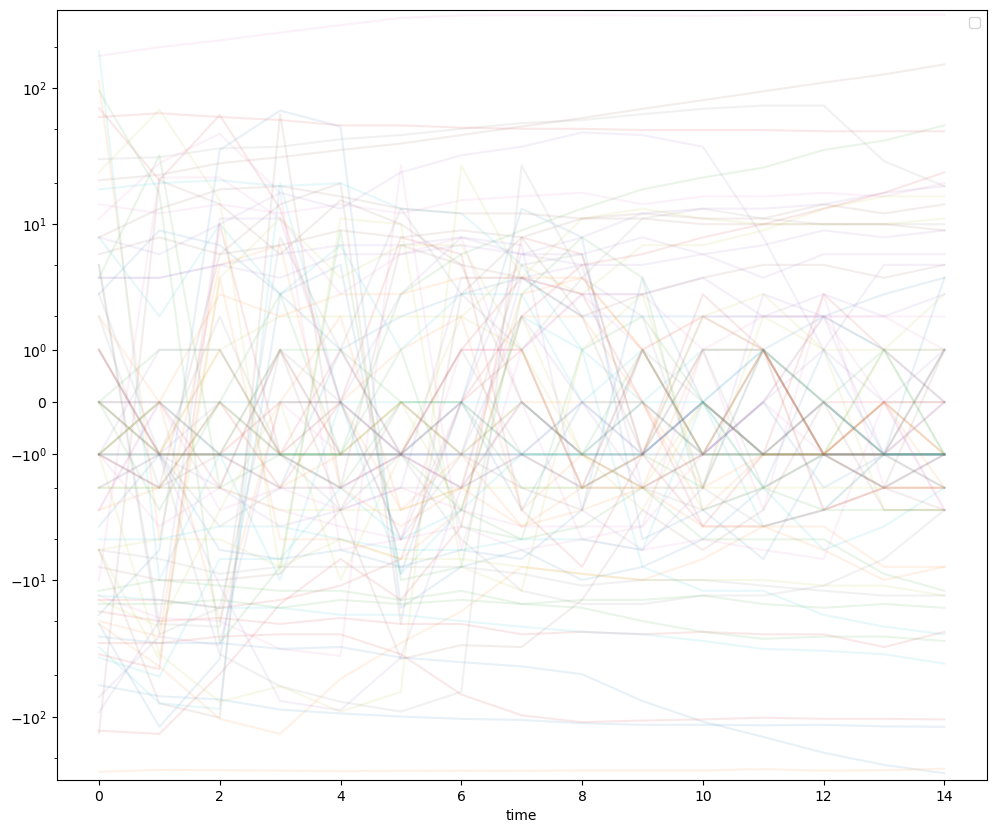

In [71]:
fig, ax = plt.subplots(figsize=(12, 10))
timeseries.groupby("id").apply(lambda df: df.plot(x="time", y="F_x", alpha=0.1, ax=ax))
ax.set_yscale("asinh")
ax.legend("")

In [72]:
from tsfresh import extract_features
extracted_features = extract_features(timeseries, column_id="id", column_sort="time")

Feature Extraction: 100%|█| 20/20 [00:06<00


In [74]:
extracted_features

,F_x__variance_larger_than_standard_deviation,F_x__has_duplicate_max,F_x__has_duplicate_min,F_x__has_duplicate,F_x__sum_values,F_x__abs_energy,F_x__mean_abs_change,F_x__mean_change,F_x__mean_second_derivative_central,F_x__median,...,T_z__fourier_entropy__bins_5,T_z__fourier_entropy__bins_10,T_z__fourier_entropy__bins_100,T_z__permutation_entropy__dimension_3__tau_1,T_z__permutation_entropy__dimension_4__tau_1,T_z__permutation_entropy__dimension_5__tau_1,T_z__permutation_entropy__dimension_6__tau_1,T_z__permutation_entropy__dimension_7__tau_1,T_z__query_similarity_count__query_None__threshold_0.0,T_z__mean_n_absolute_max__number_of_maxima_7
1,0.0,0.0,1.0,1.0,-14.0,14.0,0.142857,0.000000,-0.038462,-1.0,...,NaN,NaN,NaN,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,NaN,0.000000
2,0.0,1.0,1.0,1.0,-13.0,25.0,1.000000,0.000000,-0.038462,-1.0,...,1.073543,1.494175,2.079442,0.937156,1.234268,1.540306,1.748067,1.831020,NaN,0.571429
3,0.0,0.0,1.0,1.0,-10.0,12.0,0.714286,0.000000,-0.038462,-1.0,...,1.386294,1.732868,2.079442,1.265857,1.704551,2.019815,2.163956,2.197225,NaN,0.571429
4,0.0,1.0,1.0,1.0,-6.0,16.0,1.214286,-0.071429,-0.038462,0.0,...,1.073543,1.494175,2.079442,1.156988,1.907284,2.397895,2.302585,2.197225,NaN,1.000000
5,0.0,0.0,0.0,1.0,-9.0,17.0,0.928571,-0.071429,0.038462,-1.0,...,0.900256,1.320888,2.079442,1.156988,1.863680,2.271869,2.302585,2.197225,NaN,0.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,1.0,1.0,0.0,1.0,-1073.0,96833.0,7.142857,-5.428571,-0.038462,-98.0,...,0.735622,0.735622,1.386294,1.585771,1.907284,2.098274,2.302585,2.197225,NaN,24.285714
85,1.0,0.0,1.0,1.0,143.0,1683.0,1.357143,1.071429,0.076923,8.0,...,0.735622,0.735622,1.667462,1.332245,1.308605,1.893788,2.163956,2.197225,NaN,5.571429
86,1.0,0.0,0.0,0.0,961.0,83497.0,9.071429,9.071429,0.807692,52.0,...,0.735622,1.073543,1.732868,0.687092,0.983088,1.159589,1.227529,1.303092,NaN,9.285714
87,1.0,1.0,0.0,1.0,4509.0,1405437.0,12.928571,12.214286,-1.038462,338.0,...,0.735622,0.735622,1.386294,0.535961,0.836988,1.159589,1.497866,1.581094,NaN,40.285714


In [75]:
4734/6

789.0

In [76]:
y

1      True
2      True
3      True
4      True
5      True
      ...  
84    False
85    False
86    False
87    False
88    False
Length: 88, dtype: bool

In [77]:
from tsfresh import select_features
from tsfresh.utilities.dataframe_functions import impute

impute(extracted_features)
features_filtered = select_features(extracted_features, y)

In [78]:
features_filtered

,F_x__value_count__value_-1,F_x__root_mean_square,F_x__abs_energy,T_y__absolute_maximum,F_x__mean_n_absolute_max__number_of_maxima_7,F_x__range_count__max_1__min_-1,F_y__abs_energy,F_y__root_mean_square,F_y__mean_n_absolute_max__number_of_maxima_7,T_y__standard_deviation,...,T_x__quantile__q_0.1,F_y__has_duplicate_max,T_y__lempel_ziv_complexity__bins_3,T_y__quantile__q_0.1,F_z__time_reversal_asymmetry_statistic__lag_1,F_x__quantile__q_0.2,F_y__quantile__q_0.7,F_z__permutation_entropy__dimension_4__tau_1,"T_x__change_quantiles__f_agg_""var""__isabs_False__qh_0.2__ql_0.0",T_z__large_standard_deviation__r_0.35000000000000003
1,14.0,0.966092,14.0,1.0,1.000000,15.0,13.0,0.930949,1.000000,0.471405,...,-3.0,1.0,0.400000,-1.0,-5.960000e+02,-1.0,-1.0,1.698783,0.000000,0.0
2,7.0,1.290994,25.0,5.0,1.571429,13.0,76.0,2.250926,3.000000,2.054805,...,-9.2,1.0,0.533333,-3.6,-6.803846e+02,-1.0,-1.0,2.369382,0.000000,1.0
3,11.0,0.894427,12.0,5.0,1.000000,14.0,40.0,1.632993,2.142857,1.768867,...,-6.6,0.0,0.533333,-4.0,-6.170000e+02,-1.0,0.0,2.369382,0.000000,1.0
4,5.0,1.032796,16.0,6.0,1.285714,10.0,60.0,2.000000,2.428571,2.669998,...,-9.0,0.0,0.533333,-4.6,3.426308e+03,-1.0,1.0,1.979205,0.000000,0.0
5,9.0,1.064581,17.0,5.0,1.285714,13.0,46.0,1.751190,2.285714,2.039608,...,-9.6,0.0,0.466667,-5.0,-2.609000e+03,-1.0,0.8,1.979205,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,0.0,80.346334,96833.0,167.0,105.285714,0.0,42780.0,53.404120,71.428571,39.541483,...,203.2,0.0,0.533333,36.4,-7.700628e+07,-105.0,66.8,1.126929,64.000000,0.0
85,0.0,10.592450,1683.0,14.0,13.714286,0.0,1523.0,10.076375,12.142857,3.841296,...,-41.6,0.0,0.466667,1.0,-1.050785e+04,5.8,10.6,1.704551,13.555556,0.0
86,0.0,74.608757,83497.0,191.0,98.142857,0.0,21064.0,37.473546,47.714286,52.807154,...,-84.8,0.0,0.466667,19.6,-5.544922e+06,30.4,38.4,0.566086,0.250000,0.0
87,0.0,306.097697,1405437.0,471.0,340.000000,0.0,308658.0,143.447551,157.285714,80.098162,...,-139.2,0.0,0.466667,272.6,-9.881845e+07,246.8,154.8,1.126929,0.000000,0.0


In [79]:
from tsfresh import extract_relevant_features

features_filtered_direct = extract_relevant_features(timeseries, y,
                                                     column_id='id', column_sort='time')

Feature Extraction: 100%|█| 20/20 [00:06<00


What is the problem with this approach?

#### Text → TF-IDF

In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer

tiny_corpus = [
    "supernova type Ia bright peak",
    "variable star RR Lyrae short period",
    "active galactic nucleus quasar variable",
    "supernova type II hydrogen lines",
]
tfidf = TfidfVectorizer(stop_words='english')
X_text = tfidf.fit_transform(tiny_corpus)
pd.DataFrame(X_text.toarray(), columns=tfidf.get_feature_names_out()).round(2)

,active,bright,galactic,hydrogen,ia,ii,lines,lyrae,nucleus,peak,period,quasar,rr,short,star,supernova,type,variable
0,0.00,0.49,0.00,0.00,0.49,0.00,0.00,0.00,0.00,0.49,0.00,0.00,0.00,0.00,0.00,0.38,0.38,0.00
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.42,0.00,0.00,0.42,0.00,0.42,0.42,0.42,0.00,0.00,0.33
2,0.47,0.00,0.47,0.00,0.00,0.00,0.00,0.00,0.47,0.00,0.00,0.47,0.00,0.00,0.00,0.00,0.00,0.37
3,0.00,0.00,0.00,0.49,0.00,0.49,0.49,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.38,0.38,0.00


For text in a real classification pipeline, `TfidfVectorizer` becomes a step in `ColumnTransformer` alongside the numeric pipe.

#### Images → moments, augmentation
Skipped here. The pattern: `albumentations` augmentation pipelines are applied to *training batches only*; never to validation/test images.

> **Exercise.** Pick three columns from this dataset that you think *physically* should interact (a color and a magnitude, an amplitude and a period…). Add one as a ratio or product, score, and report the change in CV f1_macro.

## 6. Splitting beyond random

`train_test_split(shuffle=True)` is wrong when:
- **Classes are imbalanced** → `stratify=y`
- **Data has a temporal order** → `TimeSeriesSplit`; the future may never appear in training
- **Multiple rows belong to one entity** (same patient, same astronomical object) → `GroupKFold`; otherwise the model memorizes the entity

### Stratified k-fold

In [81]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for i, (tr, va) in enumerate(skf.split(X_train, y_train)):
    print(f"fold {i}: train class fractions = "
          + ", ".join(f"{c}:{y_train.iloc[tr].value_counts(normalize=True).get(c, 0):.2f}"
                      for c in sorted(y_train.unique())[:3]) + " …")

fold 0: train class fractions = AGN:0.04, EA:0.04, EB/EW:0.25 …
fold 1: train class fractions = AGN:0.04, EA:0.04, EB/EW:0.25 …
fold 2: train class fractions = AGN:0.04, EA:0.04, EB/EW:0.25 …
fold 3: train class fractions = AGN:0.04, EA:0.04, EB/EW:0.25 …
fold 4: train class fractions = AGN:0.04, EA:0.04, EB/EW:0.25 …


### `TimeSeriesSplit` — never let the future leak

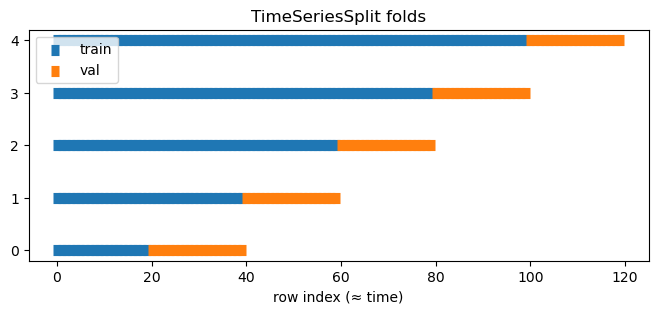

In [82]:
from sklearn.model_selection import TimeSeriesSplit

# Visualize the fold structure
fig, ax = plt.subplots(figsize=(8, 3))
n = 120
tscv = TimeSeriesSplit(n_splits=5)
for i, (tr, va) in enumerate(tscv.split(np.arange(n))):
    ax.scatter(tr, [i]*len(tr), c='tab:blue',  marker='_', lw=8, label='train' if i==0 else "")
    ax.scatter(va, [i]*len(va), c='tab:orange', marker='_', lw=8, label='val'   if i==0 else "")
ax.set_yticks(range(5)); ax.set_xlabel('row index (≈ time)'); ax.set_title('TimeSeriesSplit folds')
ax.legend(loc='upper left');

### `GroupKFold` — when many rows share an entity

In [83]:
from sklearn.model_selection import GroupKFold

# Synthetic group leakage demo: 100 patients, 10 visits each, classify visits.
# The 'feature' is a tiny noise + the patient id — i.e. memorizing the patient solves the task.
n_patients, n_visits = 100, 10
patient_id = np.repeat(np.arange(n_patients), n_visits)
y_synth    = np.tile([0]*5 + [1]*5, n_patients)   # half each class per patient
X_synth    = (patient_id + np.random.randn(len(patient_id))*0.01).reshape(-1, 1)

from sklearn.tree import DecisionTreeClassifier
random_cv = cross_val_score(DecisionTreeClassifier(), X_synth, y_synth, cv=5).mean()
group_cv  = cross_val_score(DecisionTreeClassifier(), X_synth, y_synth,
                            cv=GroupKFold(n_splits=5), groups=patient_id).mean()
print(f"random KFold (LEAKY) accuracy: {random_cv:.3f}")
print(f"GroupKFold (correct)         : {group_cv:.3f}")

random KFold (LEAKY) accuracy: 0.500
GroupKFold (correct)         : 0.498


**Discuss.** With random folds the model memorizes patient ids and "predicts" their visits. With `GroupKFold`, the patients in the validation fold are *new patients*, and the spurious feature collapses to noise. Same lesson as §1: leakage hides as a great score.

## 7. Class imbalance without leaking

Synthetic oversampling (SMOTE, ADASYN) generates new minority-class points by interpolating between existing ones. **Rule:** resampling must happen *inside* the CV loop, on the training fold only. Resampling before splitting leaks synthetic copies of validation rows into training.

In [87]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Anti-pattern: SMOTE before CV (DON'T) ---
X_imp = SimpleImputer(strategy='median').fit_transform(StandardScaler().fit_transform(X_train))
X_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_imp, y_train)
leaky_smote = cross_val_score(LogisticRegression(max_iter=2000), X_res, y_res,
                              cv=cv, scoring='f1_macro').mean()

# --- Correct: SMOTE inside an imblearn Pipeline (only fits on train folds) ---
pipe = ImbPipeline([
    ("preproc", preproc),
    ("smote",   SMOTE(random_state=RANDOM_STATE)),
    ("model",   LogisticRegression(max_iter=2000)),
])
honest_smote = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro').mean()

print(f"SMOTE before CV (leaky)      : {leaky_smote:.3f}")
print(f"SMOTE inside pipeline (clean): {honest_smote:.3f}")

SMOTE before CV (leaky)      : 0.909
SMOTE inside pipeline (clean): 0.764


The leaky number is optimistic: when SMOTE runs on the full training set, validation rows get synthetic neighbors that look almost identical to themselves. Inside the pipeline, the validation rows are real and unseen.

### Alternatives to SMOTE

Resampling isn't the only tool. Often the cleanest fix is `class_weight='balanced'` in the model itself.

In [89]:
from sklearn.linear_model import LogisticRegression

variants = {
    "no rebalance":       Pipeline([("preproc", preproc), ("m", LogisticRegression(max_iter=2000))]),
    "class_weight=bal":   Pipeline([("preproc", preproc), ("m", LogisticRegression(max_iter=2000, class_weight='balanced'))]),
    "SMOTE in pipeline":  ImbPipeline([("preproc", preproc), ("s", SMOTE(random_state=RANDOM_STATE)),  ("m", LogisticRegression(max_iter=2000))]),
}
for name, p in variants.items():
    s = cross_val_score(p, X_train, y_train, cv=cv, scoring='f1_macro').mean()
    print(f"{name:24s} f1_macro = {s:.3f}")

no rebalance             f1_macro = 0.761
class_weight=bal         f1_macro = 0.765
SMOTE in pipeline        f1_macro = 0.764


**Discuss.** When does SMOTE help over `class_weight`? Roughly: when the minority class has a complex *structure* (multimodal, non-linear boundary) that benefits from extra synthetic samples; less so when the model can simply re-weight the loss.

## 8. Hyperparameter tuning without leaking

Tuning hyperparameters on the same folds you *report* on biases the reported score upward — you've used those folds to make a decision. The clean answer is **nested CV**:

- **Outer loop**: estimate generalization
- **Inner loop**: pick hyperparameters

We tune on `X_train` only (with inner CV) and report once on `X_test` in §9. We tune the **whole pipeline**, so every preprocessing choice is re-fit per inner fold.

In [92]:
import optuna
import lightgbm as lgb
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Use a simpler preprocessing for the tuning study (LGBM doesn't need scaling)
preproc_lgb = ColumnTransformer([("num",
    Pipeline([("impute", SimpleImputer(strategy='median'))]),
    numeric_cols)])

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 127),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 3e-1, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "verbosity":         -1,
    }
    p = Pipeline([("preproc", preproc_lgb),
                  ("model",   lgb.LGBMClassifier(**params, random_state=RANDOM_STATE))])
    return cross_val_score(p, X_train, y_train, cv=inner_cv, scoring='f1_macro').mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=20, show_progress_bar=False)
print(f"best CV f1_macro: {study.best_value:.3f}")
print("best params:", study.best_params)

best CV f1_macro: 0.802
best params: {'n_estimators': 115, 'num_leaves': 120, 'learning_rate': 0.2392783459104154, 'min_child_samples': 66}


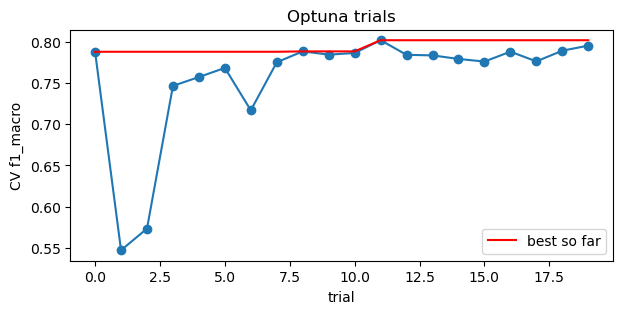

In [93]:
# Optimization history
trials = pd.DataFrame([{**t.params, "value": t.value} for t in study.trials])
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(trials.index, trials['value'], 'o-')
ax.plot(trials.index, trials['value'].cummax(), color='red', label='best so far')
ax.set_xlabel("trial"); ax.set_ylabel("CV f1_macro"); ax.legend(); ax.set_title("Optuna trials");

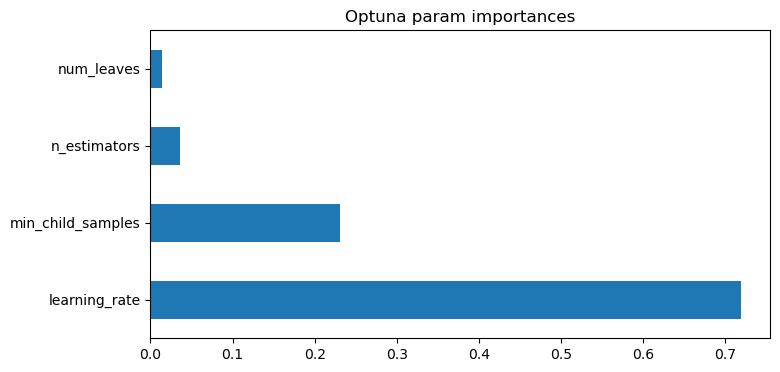

In [94]:
# Param importance
try:
    importances = optuna.importance.get_param_importances(study)
    pd.Series(importances).plot.barh(); plt.title("Optuna param importances");
except Exception as e:
    print("importance plot needs scikit-learn>=0.24:", e)

## 9. Final evaluation, and what's next 

We touch the test set exactly once. If we re-tune after seeing this number, it stops being a test set.

In [95]:
best_pipe = Pipeline([
    ("preproc", preproc_lgb),
    ("model",   lgb.LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbosity=-1)),
])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

In [96]:
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

print(f"Held-out test f1_macro: {f1_score(y_test, y_pred, average='macro'):.3f}\n")
print(classification_report(y_test, y_pred))

Held-out test f1_macro: 0.818

              precision    recall  f1-score   support

         AGN       0.78      0.47      0.58        15
          EA       0.78      0.44      0.56        16
       EB/EW       0.85      0.96      0.90        92
         LPV       0.99      0.99      0.99        90
         QSO       0.92      0.98      0.95        83
         RRL       0.95      0.91      0.93        77

    accuracy                           0.92       373
   macro avg       0.88      0.79      0.82       373
weighted avg       0.91      0.92      0.91       373



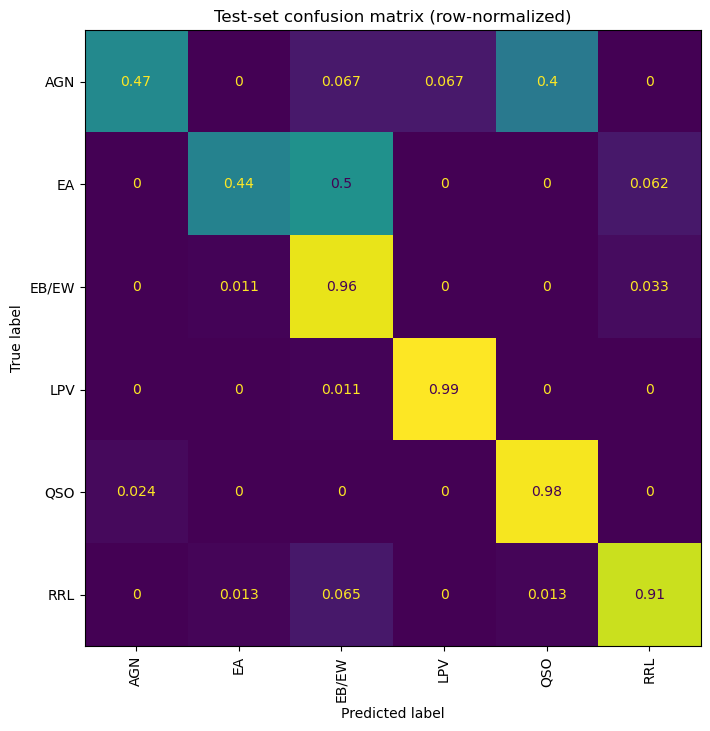

In [97]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test, ax=ax,
                                      xticks_rotation='vertical', normalize='true', colorbar=False)
ax.set_title("Test-set confusion matrix (row-normalized)");

## Moving into production

1. Tune on X_train with CV to get best_params.                                     
2. Report once on X_test to confirm the CV estimate is honest.
3. Retrain best_params on X_train + X_test combined — that's your production model.                                           
                                                                                          

Step 3 is the part that surprises people. Once the test set has done its job (giving you an unbiased generalization estimate),
 there's no reason not to use those rows for training the model you'll actually deploy. More data ⇒ usually a better model,   
and the CV/test score already told you what to expect.                                                                        
                                                                                                                            
Before you ship:
- CV stability. Look at the spread of fold scores, not just the mean. If folds are wildly different (e.g., 0.65 / 0.81 / 0.72 
/ 0.59 / 0.78), your "best" hyperparameters may have just won by noise. Prefer a slightly worse configuration with tight
folds.                                                                                                                        
- One-standard-error rule (Breiman). Among configurations whose CV score is within 1 SE of the best, pick the simplest      
(smaller model, stronger regularization). Guards against overfitting to CV noise.                                             
- Re-tune training-budget hyperparams after the data grows. If you used early_stopping against a held-out slice during tuning,
 re-fit with the same logic on the bigger combined set. For neural nets, recompute epoch count / LR schedule.                 
- Ensemble for free. Refit best_params with N different seeds on the full data, average predictions. Often a 1–3% lift with no
 new hyperparameter risk.                                                                                                     
- Time-aware data. Don't shuffle when retraining if order matters — use the most recent rows for any held-out validation, and
don't include the future in your final train.                                                                                 
                                                                                                                            
After deployment, the choice isn't really "done":                                                                             
                                                                                                                            
- Monitor input distributions and prediction distributions for drift; the CV score is your prediction of production           
performance, and production will tell you if you were right.                                                                
- Schedule a retrain cadence (weekly, monthly, drift-triggered). When you retrain, you re-tune — production data is now       
training data, and the optimum may have moved.                                                                                
- Keep the test pattern. Each retrain gets a fresh held-out slice; you don't get to claim "still good" without re-evaluating.
                                                                                                                              
The short version: CV picks the configuration, the test set verifies it, full-data refit ships it, monitoring decides when to 
redo all three.                  

### What we'd add with more time

- **Drift & retraining** — production data won't look like training data forever. Monitor distributions and schedule retraining.
- **Calibration** — predicted probabilities should match observed frequencies; `CalibratedClassifierCV`.
- **Group-aware splits in production** — design splits to mimic deployment (same entities may reappear across train/test in real life).
- **Causal vs. predictive features** — features that are downstream consequences of the target (e.g., "did the user click the confirmation email" predicting "did the user complete signup") are leakage by another name.
- **Feature stores** — once a feature is in production, the same code must compute it at training time and at inference time, or you get train/serve skew (a slow leakage).
- **Documentation** — log every preprocessing choice. The model card lives or dies by reproducibility.
